# Create Monthly Report Plots

## Libraries

In [2]:
from sodapy import Socrata
import pandas as pd
import json,csv
import os,inspect,sys
#from chlorophyll import CodeView
from tkinter import Tk
import tkinter as tk
from tkinter import ttk,Button,Label
from datetime  import datetime
#import PySimpleGUI as sg
from difflib import SequenceMatcher
import pygments.lexers
import pytz
import glob
from croniter import croniter
from cron_descriptor import get_description, ExpressionDescriptor
os.environ["BROWSER"] = "google-chrome"
import webbrowser
browsers = webbrowser._tryorder
print("Browsers detected:", browsers)
today = datetime.today()
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)
cim_url_query = 'data.colorado.gov'
datasets = None
tody = datetime.today()
#today=f"{tody.year}-{tody.month:02d}-{tody.day:02d}"    
from google.oauth2 import service_account
from googleapiclient.discovery import build
import requests
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import seaborn as sns,matplotlib.pyplot as plt
import matplotlib.dates as mdates

bic_etl_home = os.getenv('bic_etl_home')
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import requests
from requests.auth import HTTPBasicAuth


cimDatasets = {}
bicHome = "/home/joe/bic_etl"
allDatasets=[]


with Socrata(cim_url_query, None) as client:
    datasets = client.datasets()
    for dataset in datasets:
        allDatasets.append(dataset)
        if dataset['owner']['display_name'] == 'Colorado Information Marketplace':
            title=dataset["resource"]["name"]
            cimDatasets[title]=dataset

print("DONE")

ModuleNotFoundError: No module named 'cron_descriptor'

In [2]:
! pip install cron_descriptor

## Functions

In [7]:
def find_files_recursive(directory):
    # This function finds all files recursively in a given directory
    return glob.glob(f'{directory}/**/run_etl.json', recursive=True)

def decodeExtract(extract):
    
    prog=""
    lang=""
    if 'language' in extract:
        lang=extract['language']
            
    if 'file' in extract:
        prog=extract['file']
        
    else:
        print("No Prgram",lang,title,file)
    opts={}
    if 'options' in extract:
        lang=extract['language']
        for opt in extract['options']:
            opt=opt.strip()
            indx=opt.find(" ")
            o=opt[:indx]
            opts[o]= opt[indx+1:]

    return lang,prog,opts


def processRun_etls(directory_path='/home/joe/bic_etl'): 
## Get all run_etl.json files
    files = find_files_recursive(directory_path)
    
    datasets={}
    noEx=0
    groups={}
    for file in files:
        ll=len(file)
        group=file[18:-13]
        fin=open(file)
        infos = json.load(fin)
        fin.close()
        title=""
        extract=""
        for info in infos: 
            if 'title' in info:
                title=info['title']
                datasets[title]={}
                datasets[title]['extract']={}
                datasets[title]['extract']['language']=''
                datasets[title]['extract']['program']=''
                datasets[title]['extract']['options']={}
                datasets[title]['group']=group
                if group not in groups:
                    groups[group]=[]
                groups[group].append(title)
                if 'extract' in info:
                    extract=info['extract']
                    if isinstance(extract,dict):
                       lang,prog,opts=decodeExtract(extract)
                       datasets[title]['extract']['language']=lang
                       datasets[title]['extract']['program']=prog
                       datasets[title]['extract']['options']=opts
                    elif isinstance(extract,list):
                        for infoL in extract: 
                            lang,prog,opts=decodeExtract(infoL)
                            datasets[title]['extract']['language']=lang
                            datasets[title]['extract']['program']=prog
                            datasets[title]['extract']['options']=opts
                    else:
                        print("UNK",type(info))
        
            else:
                print("No Title",file)
    return datasets,groups

def getUrlAddresses(datasets):
    hist={}
    addresses={}
    options={}
    specOpts={}
    specOpts["general/scripts/request_url.js"]={}
    specOpts["general/scripts/request_url.js"]["-u"]="-f"
    
    specOpts["general/scripts/sftp_extract.js"]={}
    specOpts["general/scripts/sftp_extract.js"]["-h"]="-f"
    specOpts["general/scripts/sftp_extract.js"]["none"]="-f"
    
    specOpts["cdos/general/scripts/sftp_extract.js"]={}
    specOpts["cdos/general/scripts/sftp_extract.js"]["none"]="-f"
    
    lookupNotFound = {
    'bea/scripts/bea_msa_api_reader.py':['https://apps.bea.gov/api/data'],
    'denver/scripts/get_data.py':['https://www.denvergov.org/content/dam/denvergov/Portals/covid19/documents/Denver-Approved-Patio-Expansion-List.xlsx'],
    'scripts/extract_liquor_files.py':'https://sbg.colorado.gov/liquor-license-lists',
    'county_sales_extract.py':['https://docs.google.com/spreadsheets/d/1br_cwfHy24d2R2bcXacb2KarOIBKGrbR/export?format=csv'],
    'scripts/county_salestax_extract.py':['https://docs.google.com/spreadsheets/d/1EhlDIrXjJdmg_ob2eMFeN5xtyvTq2jtr/export?format=csv'],
    'scripts/tax_fee_extract.py':['https://docs.google.com/spreadsheets/d/1e8hnG64Vkg9ffgkNpKQ1kzPsXNbGjG2X/export?format=csv'],
    'scripts/state_mar_sales_extract.py':['https://docs.google.com/spreadsheets/d/1wE7Z_1q2zxL7-kP0AqlUvL731U3Aui1l/export?format=csv'],
    'scripts/city_extract.py':['https://docs.google.com/spreadsheets/d/1wo4WKzvlfdw47_3841jD2RUibbDwos3L/export?format=csv','https://docs.google.com/spreadsheets/d/1WI2jvRCzBqYFIPA2vsUmCjHedKCQD911/export?format=csv'],
    'scripts/county_extract.py':['https://docs.google.com/spreadsheets/d/1irLP8K7jREdDgIiamgZ2MiTbkeMX5lrM/export?format=csv'],
    'scripts/extract_scripts/citybyindustry_extract.py':['https://docs.google.com/spreadsheets/d/1ZKc0olDlChHyRiLlxL3ECxKqBYtyaUaB/export?format=csv','https://docs.google.com/spreadsheets/d/1E6VqKiPnUD3LMnrSBy1aEYSc4QsU6Y9v/export?format=csv'],
    'scripts/extract_scripts/industry_extract.py':['https://docs.google.com/spreadsheets/d/{1WANzZQFE57J73daXvo1xu4mITy-1DmuP/export?format=csv','https://docs.google.com/spreadsheets/d/1cmTJ4ZRAjBFfevT0hyCatUXDIzIG393I/export?format=csv'],
    'scripts/extract_scripts/countybyindustry_extract.py':['https://docs.google.com/spreadsheets/d/1CI66-qv0ooK93asc21VyV-tJiYSc2J3c/export?format=csv','https://docs.google.com/spreadsheets/d/1kybUGf02krqwyl8yBPHnTbn0iQT4Cnnz/export?format=csv'],
    'scripts/extract_liquor_files.py':['https://sbg.colorado.gov/liquor-license-lists']
    }
    
    
    noProg={}
    for title,dct in datasets.items():
        if 'group' in dct:
            group=dct['group']
        else:
            group=""
        if 'extract' in dct:
            if 'language' in dct['extract']:
                lang=dct['extract']['language']
                prog=dct['extract']['program']
                if lang not in hist:
                    hist[lang]={}
                if prog not in hist[lang]:
                    hist[lang][prog]=0
                hist[lang][prog]+=1
    
                if prog not in addresses:
                    addresses[prog]={}
                if 'options' in dct['extract']:
                    if prog in specOpts:
                        o=list(specOpts[prog].keys())[0]
                        fOpt=specOpts[prog][o]
                        ff = dct['extract']['options'][fOpt]  
                        if o in dct['extract']['options']:
                            a=dct['extract']['options'][o]
                        else:
                            if prog == "general/scripts/sftp_extract.js":
                              a="ftps.sos.state.co.us"
                            else:
                              a=""
                    else:
                        ff=""
                        o=""
                        a=""
                        if prog in lookupNotFound:
                            a = lookupNotFound[prog]
                        else:
                            if prog not in noProg:
                                noProg[prog]={}
                            noProg[prog]['group']=group
                        
                    if isinstance(a,str):
                        b=[]
                        b.append(a)
                    else:
                        b=a
                    for a in b: 
                        if a not in addresses[prog]:
                            addresses[prog][a]={}
                        if ff not in addresses[prog][a]:
                           addresses[prog][a][ff]={}
                        
                        if title not in addresses[prog][a][ff]:
                           addresses[prog][a][ff][title]={}
                            
                           addresses[prog][a][ff][title]['count']=0
                           addresses[prog][a][ff][title]['group']=group
                        
                        
                    addresses[prog][a][ff][title]['count']+=1
##  Create a DataFrame
    programs=[]
    address=[]
    files=[]
    counts=[]
    titles=[]
    groups=[]
    for p,dct in addresses.items():
        for o,dct2 in dct.items():   
            for f,dct3 in dct2.items():
                for t,dct4 in dct3.items():
                    
                    programs.append(p)
                    address.append(o)
                    files.append(f)
                    counts.append(dct4['count'])
                    groups.append(dct4['group'])
                    
                    titles.append(t)
    df = pd.DataFrame({
        "Title":titles,
        "Group":groups,
        "Program":programs,
        "Address":address,
        "File":files,
        "Count":counts})
    return addresses,df

## Collect CRON Info from cron File

def getCronInfo(cron_file_path):
    fin=open(cron_file_path)
    lines=fin.readlines()
    crons={}
    for line in lines:
        if line[0:1] != "#" and line[0:1] != " " and len(line) > 2:
            line=line.strip()
            spl=line.split()
            crn=' '.join(spl[:5])
            rest = ' '.join(spl[5:])
            
            crons[rest]=crn
    return crons

def decodeCron(cron_file):
    hist={}
    cronGroups={}
    crons=getCronInfo(cron_file)
    for inf,crn in crons.items():
    
        desc = get_description(crn)
        spl=inf.split()
        lang=spl[0]
        prg=spl[1]
        indxP=inf.find("-p")
        if indxP > -1:
           tmp=inf[indxP+2:].lstrip()
           end=tmp.find(" ")
           grp=tmp[:end]
        else:
            grp=""
    
        indxT=inf.find("-t")
        if indxT > -1:
           tmp=inf[indxT+2:].lstrip()
           start = tmp.find('"')
           end=tmp[start+1:].find('"')
           titl=tmp[start+1:end+1]
        else:
            titl="ALL"
        if grp not in cronGroups:
            cronGroups[grp]={}
        cronGroups[grp][titl]=desc
  #      print(grp,titl)     
        if lang not in hist:
            hist[lang]={}
        if prg not in hist[lang]:
            hist[lang][prg]=0
        hist[lang][prg]+=1
    return cronGroups

## Combine Dataset ETL Info and CRON Info 
def addCronInfo(row):
    title=row['Title']
    group=row['Group']
#    print(group,title)
    if group in cronGroups:
        dct=cronGroups[group]
        if title in dct:
            cron=cronGroups[group][title]
        elif "ALL" in dct:
            cron=cronGroups[group]["ALL"]
        else:
            cron="Unknown"   
            
        # for how,crn in dct.items(): 
        #     print("  ",how,crn)
        #     if title in cronGroups[group]:
        #        cron=cronGroups[group][title]
        #        break
        #     elif how == "ALL":
        #         cron=crn
        #         break
        #     else:
        #         cron="Unknown"
        #         print("    Unknown ",how,title,crn)

    else:
        cron="No Group Found"
    return cron

## Activity Functions

In [8]:
def getActivityLog():
    flog=open(f"{bic_etl_home}/general/datasync/config.json")
    info = json.load(flog)
    username=info['username']
    password=info['password']
    api=info['appToken']
#    "$where": "created_at > '2023-01-01T00:00:00' and acting_user_name = 'Colorado Information Marketplace'"
    
    # URL of the login form
    query = {
    "$where": "created_at > '2023-01-01T00:00:00' and acting_user_name = 'Colorado Information Marketplace'"
    }
    login_url = 'https://data.colorado.gov/api/activity_log.json?$limit=6000000'
    response=requests.get(login_url,auth=(username, password),params=query)
    if response.status_code == 200:
      
#        activity_log=json.loads(response.text)
        print(type(response.text))
    else:
        print("Failed to download Activity Log")
        print(f"Error: {response.status_code}")
        print(f"Message: {response.text}")
    return pd.DataFrame(json.loads(response.text))



def createReport(summary,lastActivityDate):
    report={}
    for title,dct in summary.items():
        if "Expected Update" in dct: 
            expt = dct["Expected Update"]
            lastSuccess= dct["Activity Data Success"]
            if expt not in report:
                report[expt]={}
                report[expt]["Pass"]=0
                report[expt]["Fail"]=0
                report[expt]["Total"]=0
            
            report[expt]["Total"]=0
            
            if lastSuccess == "NA":
                report[expt]["Fail"]+=1
                what="Fail"
            else:
                lastSuccessn=int(lastSuccess)
                exptn=int(expt)
                if exptn >= lastSuccessn:
                   report[expt]["Pass"]+=1
                   what="Pass"
                else:
                   report[expt]["Fail"]+=1
                   what="Fail"
          #  print(f"{expt:4d} {str(lastSuccess):4s}  {what:4s}  {title}")
        else:
            print("ROH ROH ",title,dct)

    tody=datetime.today().date()
    ndf=tody-lastActivityDate

    mapped = {1:"Daily",7:"Weekly",31:"Monthly",90:"Quarterly",365:"Annual"}
    fout=open("/home/joe/reportSummary.txt","w")
    fout.write(f"Date: {datetime.today().date()}\n")
    fout.write(f"Last Date in Activity Log: {lastActivityDate}\n")
    fout.write(f"Age of  Activity Log (Days): {ndf.days}\n")
    
    
    sumr=[]
    for how,dct in report.items():
     #  print(f"{mapped[how]:10s}  Passed: {dct['Pass']:4d}  Fail:{dct['Fail']:4d}")
        fout.write(f"{mapped[how]:10s}  Passed: {dct['Pass']:4d}  Fail:{dct['Fail']:4d}\n")
        sumr.append([mapped[how],dct['Pass'],dct['Fail']])
        
    fout.close()
 
    layout = [
         [sg.Text(f"Summary Report for {datetime.today()}",font='Courier 25 bold ')],
         [sg.Button('Quit',font='Courier 15 bold ')],
         [sg.Text(f"Last Date in Activity Log {lastActivityDate}",font='Courier 15 bold ')],
         [sg.Text(f"Activity Log Age in Days {ndf.days}",font='Courier 15 bold ')],
         [sg.Text("Report Output to File: /home/joe/reportSummary.txt",font='Courier 15 bold ')],
         [sg.Table(values=sumr,headings=["Cadence","Pass","Fail"],font='Courier 15 bold ')]
         ]
   

   
    window2 = sg.Window('Automated Group Info', layout,margins=(25,25),finalize=True,resizable=True,background_color="#cc4400")
    return report



def convDateTime(string,format,type):
   if type == 1: # Convert Date Time string to Date Time Object
        dateTime=datetime.strptime(string,format)
        # Convert Zulu Time to Mountain Time
        if format.find("Z") > -1:
            utc_timezone = pytz.utc
            zulu_time = utc_timezone.localize(dateTime)
            
            # Define the local timezone (e.g., US/Eastern)
            local_timezone = pytz.timezone("US/Mountain")
            
            # Convert the Zulu time (UTC) to local time
            dateTime = zulu_time.astimezone(local_timezone)
            # Convert the offset-aware datetime to offset-naive by removing the timezone info
            dateTime=dateTime.replace(tzinfo=None)
        return dateTime
       

def getCimInfo(df):
    notFound=[]
    mapped = {
    "Manual - annual":365,       
    "Automated - monthly":31,    
    "Automated - daily":1,      
    "Automated - weekly":7,      
    "Manual - quarterly":90,                          
    "Manual - monthly":31}        
    
    tody = datetime.today()
    hist={}
    for indx,row in df.iterrows():
        title=row["Dataset Title"]
        expctdUpdt = row["Update Type"]
      #  print("Expet:",expctdUpdt)
        nexpctdUpdt=mapped[expctdUpdt]
        if title  in cimDatasets:    
            cimUpdtMeta = cimDatasets[title]["resource"]["updatedAt"]
            cimUpdtData = cimDatasets[title]["resource"]["data_updated_at"]
            
            cimUpdtMeta=convDateTime(cimUpdtMeta, "%Y-%m-%dT%H:%M:%S.%fZ",1)
            cimUpdtData=convDateTime(cimUpdtData, "%Y-%m-%dT%H:%M:%S.%fZ",1)
      
            diffMeta = tody-cimUpdtMeta
            diffData = tody-cimUpdtData
            typ=cimDatasets[title]['resource']['type']
            diffMeta=round(diffMeta.total_seconds()/(24 * 60 * 60))
            diffData=round(diffData.total_seconds()/(24 * 60 * 60))
            if title not in hist:
                hist[title]={}
            hist[title]["Meta"]=diffMeta
            hist[title]["Data"]=diffData
            hist[title]["Expected"]=nexpctdUpdt
            hist[title]["Type"]=typ
            
    
        else:
            notFound.append(title)
    return hist


def getDatasetTrackerInfo(bic_etl_home):

    scope = ['https://www.googleapis.com/auth/spreadsheets.readonly',
                 "https://www.googleapis.com/auth/drive.file",
                      "https://www.googleapis.com/auth/drive"]
    
    #creds = ServiceAccountCredentials.from_json_keyfile_name('../../scripts/client_secret.json',
    #    scope)
    creds = ServiceAccountCredentials.from_json_keyfile_name(os.path.join(bic_etl_home, 'general', 'scripts','client_secret.json'),scope)
    
    client = gspread.authorize(creds)
    tracker = client.open('BIC Dataset Tracker').worksheet(
    'PublishedData')
    dfTracker = pd.DataFrame(tracker.get_all_records(head=2))
    return dfTracker

    
def analysis(hist,dfActivity):
    data=[]
    which="Data"
    logInfo={}
    counts=[]
    fails=["DataUpdate.Import.Failure","DataUpdate.Replace.Failure","DataUpdate.Import.Failure"]
    success=["DataUpdate.Replace.Success"]
    failsSched=["ScheduleFailedFatally"]
    successSched=["ScheduleSucceeded"]
    tody=datetime.today()
    summary={}
    allAuto={}
    lastActivityDate=None
    for title,dct in sorted(hist.items(), key=lambda item: item[1][which]):
       
        if dct[which] > dct["Expected"]:
         #   data.append([title,dct["Data"]-dct["Expected"],dct["Data"],dct["Expected"],dct["Meta"]])
            tmp=dfActivity.loc[dfActivity["affected_item"] == title]
            summary[title]={}
            allAuto[title]={}
            
            if tmp.shape[0] > 0:
                for indx,row in tmp.iterrows(): 
                    activity = row["activity_type"]
                    cdate=row["created_at"]
                    cdate = convDateTime(cdate, "%Y-%m-%dT%H:%M:%S.%fZ",1)
                    ndays=round((tody-cdate).total_seconds()/(24 * 60 * 60))
                    cdate=cdate.date()
                    if not lastActivityDate:
                        lastActivityDate=cdate
                    else:
                        if cdate > lastActivityDate:
                            lastActivityDate=cdate
                    if title not in logInfo:
                        logInfo[title]={}
                    if activity not in logInfo[title]:
                       logInfo[title][activity]={}
                    # if cdate not in logInfo[title][activity] = {}
                    #     logInfo[title][activity][cdate]={}
                    logInfo[title][activity][cdate]=ndays
                       
                dataFailsMax=None
                dataSuccessMax=None
                dataSuccessSchedMax=None
                dataFailsSchedMax=None
    
                
            
                for act,dct2 in logInfo[title].items():
                    mx=max(dct2.keys())
                    mn=min(dct2.keys())
            
                    if act in fails:
                        if not dataFailsMax:
                            dataFailsMax=mx
                        else:
                            if mx > dataFailsMax:
                                dataFailsMax=mx
                    elif act in success:
                        if not dataSuccessMax:
                            dataSuccessMax=mx
                        else:
                            if mx > dataSuccessMax:
                                dataSuccessMax=mx
                    elif act in failsSched:
                        if not dataFailsSchedMax:
                            dataFailsSchedMax=mx
                        else:
                            if mx > dataFailsSchedMax:
                                dataFailsSchedMax=mx
                    elif act in successSched:
                        if not dataSuccessSchedMax:
                            dataFailsSuccessMax=mx
                        else:
                            if mx > dataSuccessSchedMax:
                                dataSuccessSchedMax=mx  
                                
                tody=datetime.today()
                if dataFailsMax:
                    dataFailsNdays=round((tody.date() - dataFailsMax).total_seconds() / (24 * 3600))
                else:
                    dataFailsNdays="NA"
        
                if dataSuccessMax:
                    dataSuccessNdays=round((tody.date() - dataSuccessMax).total_seconds() / (24 * 3600))
                else:
                    dataSuccessNdays="NA"
        
                if dataFailsSchedMax:
                    dataFailsSchedNdays=round((tody.date() - dataFailsSchedMax).total_seconds() / (24 * 3600))
                else:
                    dataFailsSchedNdays="NA"
        
                if dataSuccessSchedMax:
                    dataSuccessSchedNdays=round((tody.date() - dataSuccessSchedMax).total_seconds() / (24 * 3600))
                    
                else:
                    dataSuccessSchedNdays="NA"

                what=""
                expt=dct["Expected"]
                if dataSuccessNdays == "NA":
                    what="Fail"
                else:
                    lastSuccessn=int(dataSuccessNdays)
                    exptn=int(expt)
                    if exptn >= lastSuccessn:
                       what="Pass"
                    else:
                       what="Fail"

                summary[title]["Data-Expected"]= dct["Data"]-dct["Expected"]
                summary[title]["Data Update"]= dct["Data"]
                summary[title]["Expected Update"]= dct["Expected"]
                summary[title]["Meta Update"]= dct["Meta"]
                summary[title]["Activity Data Success"]= dataSuccessNdays
                summary[title]["Activity Data Fail"]= dataFailsNdays
                summary[title]["Activity Scheduled Success"]= dataSuccessSchedNdays
                summary[title]["Activity Scheduled Fail"]= dataFailsSchedNdays     

                allAuto[title]["Data-Expected"]= dct["Data"]-dct["Expected"]
                allAuto[title]["Data Update"]= dct["Data"]
                allAuto[title]["Expected Update"]= dct["Expected"]
                allAuto[title]["Meta Update"]= dct["Meta"]
                allAuto[title]["Activity Data Success"]= dataSuccessNdays
                allAuto[title]["Activity Data Fail"]= dataFailsNdays
                allAuto[title]["Activity Scheduled Success"]= dataSuccessSchedNdays
                allAuto[title]["Activity Scheduled Fail"]= dataFailsSchedNdays     
                allAuto[title]["Status"]= 'fail'
                allAuto[title]["Type"]= dct["Type"]
                
                
                data.append([title,dct["Data"]-dct["Expected"],dct["Data"],dct["Expected"],dct["Meta"],what,dataSuccessNdays,dataFailsNdays,dataSuccessSchedNdays,dataFailsSchedNdays])
            else:
                print("NO INFO FOR ",title)
        else:
                allAuto[title]={}
                allAuto[title]["Status"]= 'pass'
                allAuto[title]['Expected Update'] = dct["Expected"]
                allAuto[title]["Type"]= dct["Type"]
             
    return logInfo,data,summary,lastActivityDate,allAuto

    
def analyzeActivityLog(title,logInf):
    try:
        histActivity={}
        acts=[]
        durs=[]
        mins=[]
        maxs=[]
        counts=[]
        for act,dct2 in logInf.items():
            mx=max(dct2.keys())
            mn=min(dct2.keys())
            acts.append(act)
            mins.append(mn)
            maxs.append(mx)
       #     dur=(mx-mn).total_seconds() / (24 * 3600)
            dur=(mx-mn)
            counts.append(len(dct2.keys()))
            durs.append(dur)
            if act not in histActivity:
                histActivity[act]=0
            histActivity[act]+=1
                             
                                         
        dfa=pd.DataFrame({"Activity":acts,"Duration":durs,"Start":mins,"Ends":maxs,"Counts":counts})
        fig, ax = plt.subplots()
        #df['duration'] = (df['end'] - df['start']).dt.total_seconds() / (24 * 3600)
    #    fig.figure(figsize=(10, 6))
        sns.set(style="whitegrid")
        
        # Plot rectangles for each task
        for index, row in dfa.iterrows():
            plt.barh(index, row['Duration'], left=row['Start'], height=0.4, edgecolor='black')
            start=row["Start"]
            duration=row["Duration"]
            count=row["Counts"]
            ax.text(start + duration / 2, index, f"{count}", va='center', ha='center', color='white', fontsize=9)
        
        # Setting labels
        ax.set_yticks(range(len(dfa['Activity'])), dfa['Activity'])
        ax.set_xlabel('Date')
        ax.set_title(f"Activity Log for {title}")
        
        # Format the x-axis to show dates
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # Set the formatter to display the date in a readable format (Year-Month-Day)
        # Rotate and align the x labels for better readability
        plt.xticks(rotation=90, ha="right")
      #  ax.set_xticklabels(ax.get_xticks(), rotation=90)
        # Show grid lines for better readability
        ax.grid(False, linestyle='--', alpha=0.5)
        ax.set_xlim(left=None, right=tody)
        # Show the plot
        fig.tight_layout()
    
        layout = [
            [sg.Text('Actvity Log Analysis')],
            [sg.Canvas(key='-CANVAS-')],
            [sg.Button('Quit')]
        ]
        
        # Create the PySimpleGUI window
        window = sg.Window('Activity Log Analysis', layout, finalize=True)
        
        # Draw the plot on the canvas
    #    draw_figure(window['-CANVAS-'].TKCanvas, fig)
        figure_canvas_agg = FigureCanvasTkAgg(fig, window['-CANVAS-'].TKCanvas)
        figure_canvas_agg.draw()
        figure_canvas_agg.get_tk_widget().pack(side='top', fill='both', expand=1)
    except Exception as err:
        print("Error in Activity Analysis ",err) 

def activeGui():
#   dfActivity = pd.read_csv("Activity_Log_2025-02-03.csv")
   dfActivity = getActivityLog()
   dfTracker=getDatasetTrackerInfo(bic_etl_home)
   dfTrackerNotStatic = dfTracker.loc[~dfTracker["Update Type"].isin(["Static",""])]
   hist=getCimInfo(dfTrackerNotStatic)
   logInfo,data,summary,lastActivityDate,allAuto=analysis(hist,dfActivity)
   header=["Title","Data-Expected","Data Update","Expected Period","Metadata Update","Smell Test","Last Success","Last Failure",
           "Sched Success","Sched Fail"]
   data=sorted(data, key=lambda item: item[1],reverse=True)
 
   layoutS = [
         [sg.Button('Quit',font='Courier 15 bold ')],
         [sg.Text(f"Last Date in Activity Log: {lastActivityDate}",font='Courier 15 bold ')],
         [sg.Text(f"Today: {datetime.today().date()}",font='Courier 15 bold ')],
         [sg.Text(f"Age of Activity Log (Days): {(datetime.today().date()-lastActivityDate).days}",font='Courier 15 bold ')],
       
         [sg.Button("Create Report",key="-REPORT-")],
         [sg.Table(values=data,headings=header,col_widths=[50,15,15,15,15,15,15,15,15,15],cols_justification=["l","c","c","c","c","c","c","c","c","c"],
                   num_rows=30,row_height=40,vertical_scroll_only=False,auto_size_columns=False,
                   enable_events=True, key='-TABLE-',border_width=6,background_color = "#99ccff",
                   alternating_row_color = "#9999ff",font="CENTAUR 10 bold")]
    ]
   layout = [[ sg.Column(layoutS,scrollable=True)]]
   window3 = sg.Window('Activity GUI', layout,finalize=True,resizable=True,background_color="#cc4400")

   sourceDefFile=""  #  this is needed
   vals=[]
   return logInfo,data,summary,lastActivityDate,allAuto

def getAssetDataset():
    flog=open(f"{bic_etl_home}/general/datasync/config.json")
    info = json.load(flog)
    username=info['username']
    password=info['password']
    api=info['appToken']
    
    # URL of the login form
    query = {
    "$where": "timestamp > '2013-01-01T00:00:00' "
    }
    login_url = 'https://data.colorado.gov/resource/pb79-5bvp.json?$limit=4000000'
    response=requests.get(login_url,auth=(username, password))
    if response.status_code == 200:
      
#        activity_log=json.loads(response.text)
     #   print(type(response.text))
    else:
        print("Failed to download Activity Log")
        print(f"Error: {response.status_code}")
        print(f"Message: {response.text}")
    return pd.DataFrame(json.loads(response.text))


## Create Plots

No Title /home/joe/bic_etl/general/example/run_etl.json
 ALL
 
 ALL
bls/sm ALL
boulder Septic Systems in Boulder County Colorado
catalog ALL
cdos/business/nonprofit ALL
cdos/business/nonprofit Registration of Charities, Paid Solicitors, Professional Fundraising Consultants, and for-profit Public Benefit Corporations in Colorado
cdos/business/business Business Entities in Colorado
cdos/business/business Business Entity Transaction History
cdos/health ALL
cdos/lobbyist ALL
cdos/government ALL
cdos/business/business Master List in Colorado
cdos/business/business Trade Names for Businesses in Colorado
cdos/business/business Trademarks for Businesses in Colorado
cdos/business/ucc ALL
cdot/transportation_road_attributes ALL
cdot/transportation_infrastructure ALL
cdot/natural_resources ALL
cdot/tops ALL
dola/boundaries ALL
dola/special_districts ALL
dola/demographics ALL
cdor/revenue_marijuana ALL
cdor/retail_reports ALL
cdor/regulations_liquor ALL
ceo/useia Gasoline Prices in Colorado
ceo/us

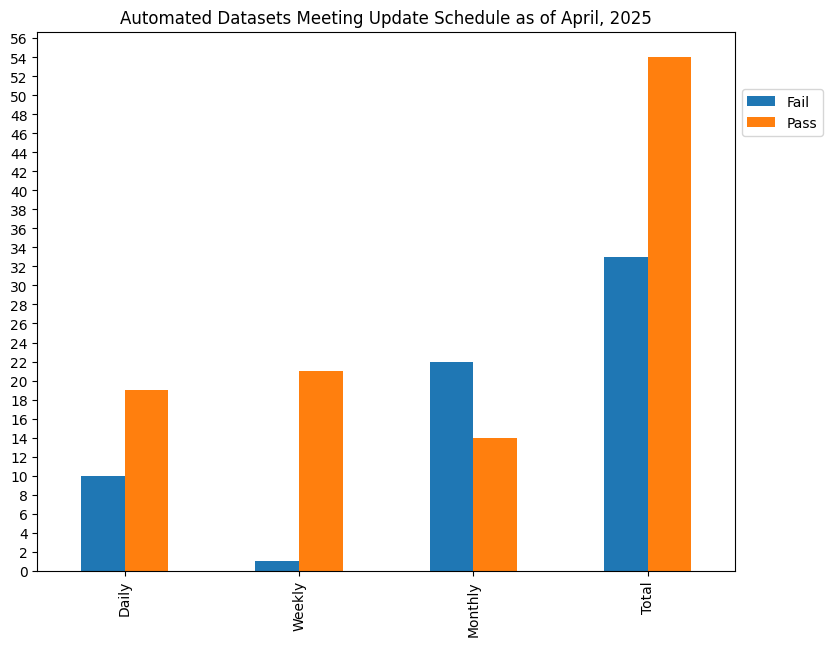

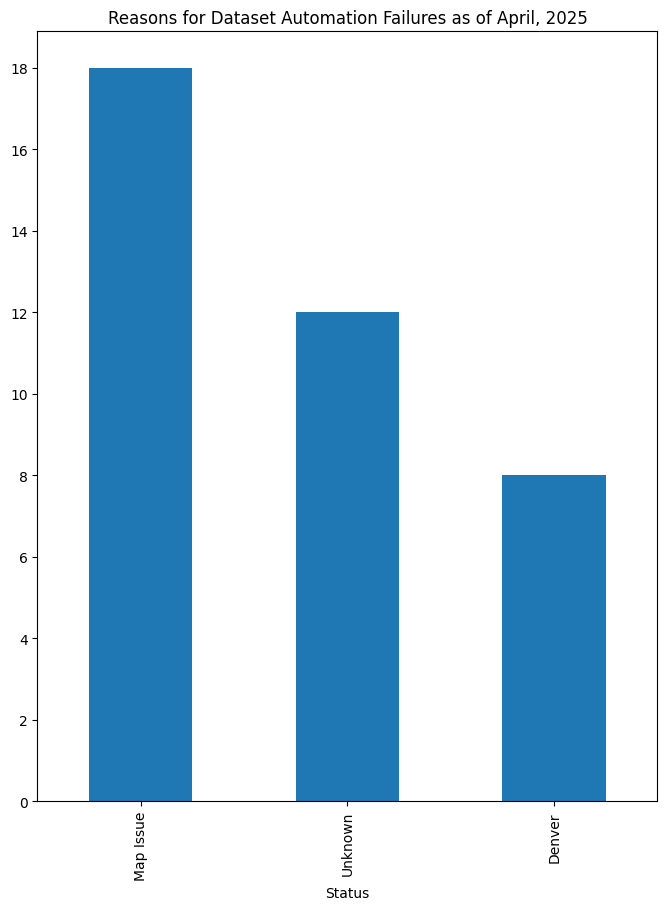

In [10]:
def generateMonthlyReport(allAuto):
    mapped = {1:"Daily",7:"Weekly",31:"Monthly",90:"Quarterly",365:"Annual"}
    hist={}
    histNew={}
    badTitles={}
    for title,dct in allAuto.items():
        stat = dct["Status"]
        expected = dct["Expected Update"]
        
        mapd=mapped[expected]
        if mapd not in hist:
            hist[mapd]={}
        if stat not in hist[mapd]:
            hist[mapd][stat]=0
        hist[mapd][stat]+=1
        if stat == "fail":
            if dct['Activity Data Success'] != 'NA'  and int(dct['Activity Data Success']) <= dct['Expected Update']:
                stat='pass'
        if stat == "fail":
            if mapd not in badTitles:
                badTitles[mapd]={}
            badTitles[mapd][title]=dct
            
        if mapd not in histNew:
            histNew[mapd]={}
        if stat not in histNew[mapd]:
            histNew[mapd][stat]=0
        histNew[mapd][stat]+=1

## Create Summary Plot
    if 'Annual' in histNew:
        del histNew["Annual"]
    if 'Quarterly' in histNew:
        del histNew['Quarterly']
 #   print (histNew)
    histPlot={}
    for key,dct in histNew.items():
        histPlot[key]={}
        if 'fail' in dct:
            histPlot[key]['Fail']=dct['fail']
        else:
            histPlot[key]['Fail']=0
        histPlot[key]['Pass']=dct['pass']
        if "Total" not in histPlot:
            histPlot["Total"]={}
            histPlot["Total"]["Fail"]=0
            histPlot["Total"]["Pass"]=0
        if 'fail' in dct:   
            histPlot["Total"]["Fail"]+=dct["fail"]
        histPlot["Total"]["Pass"]+=dct["pass"]

    tdy = datetime.today().date()
#    print("HIST PLOT ",histPlot)
    pd.DataFrame(histPlot)[["Daily","Weekly","Monthly","Total"]].T.plot.bar(figsize=(9,7))
    plt.title(f'Automated Datasets Meeting Update Schedule as of {tdy.strftime("%B")}, {tdy.year}')
    
    # Move the legend to outside of the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.85))
    plt.gca().yaxis.set_major_locator(MultipleLocator(2))
    plt.savefig("automatedStatus.png")


## Plot WHY Failing
    all=None
    
    for cron,dct in badTitles.items():
        for title,dct2 in dct.items():
     #       print("--------------\n",title)
          
            tmp=dfAssets.loc[(dfAssets["name"] == title) & (dfAssets["uid"].str.len() == 9),['uid', 'name', 'owner','creation_date','audience','publication_stage', 'last_data_updated_date']]
            tmp2 = grCronGroup.loc[grCronGroup["Title"] == title]
      
            if tmp2.shape[0] > 0:
                tmp["Group"]=tmp2["Group"].values
                tmp["Cron"]=tmp2["Cron"].values
                grp = tmp2["Group"].values.tolist()[0]
                
            else:
                tmp["Group"]=""
                tmp["Cron"]=""
                grp=""
                
            if "Data Update" in dct2 and "Expected Update" in dct2:
                tmp["Data Update CIM"]=dct2["Data Update"]
                tmp["Expected Update"]=dct2["Expected Update"]
                tmp["Diff Update"]=dct2["Data Update"]-dct2["Expected Update"]           
            else:
                tmp["Data Update CIM"]=""
                tmp["Expected Update"]=""
    
                
            if title.lower().find("denver") > -1: 
                why="Denver"
            
            elif grp == "dola/special_districts" or grp == "cdot/transportation_infrastructure" or  grp == "dola/boundaries" or  \
                 grp == "cdot/transportation_road_attributes" or grp == "cdot/natural_resources":
                 why="Map Issue"
            else:
                why="Unknown"
            tmp["Sched"]=cron
            tmp["Status"]=why
            if all is not None:
                all=pd.concat([all,tmp])
            else:
                all=tmp     

    plt.figure(figsize=(8,10))
    ax=all["Status"].value_counts().plot.bar()
    plt.title(f"Reasons for Dataset Automation Failures as of {tdy.strftime('%B')}, {tdy.year}")
    plt.gca().yaxis.set_major_locator(MultipleLocator(2))
    plt.savefig("reasons.png")

    
directory_path="/home/joe/bic_etl"    
datasetsEtlInfo,automationGroups = processRun_etls(directory_path=directory_path)
    
addresses,df = getUrlAddresses(datasetsEtlInfo) 
cron_file = '/home/joe/bic_etl/general/cron/cron_file' 
cronGroups=decodeCron(cron_file)
df["Cron"] = df.apply(addCronInfo,axis=1)
grCronGroup = df.copy()
dfAssets=getAssetDataset()

dfActivity =getActivityLog()
dfTracker=getDatasetTrackerInfo(bic_etl_home)
dfTrackerNotStatic = dfTracker.loc[~dfTracker["Update Type"].isin(["Static",""])]
hist=getCimInfo(dfTrackerNotStatic)
logInfo,data,summary,lastActivityDate,allAuto=analysis(hist,dfActivity)
generateMonthlyReport(allAuto)

print("\n\n\nUpload Files to Google Dribve at Project-Colorado-Bic/Project Deliverables-2025/Reports/Montly Reports")
print("https://drive.google.com/drive/u/0/folders/1RXTogGJBKTZubjofnveXgxgOpUD54spr")
print("Image Files are in /home/joe/work/Inventory under montlyReport.png and reasons.png")

# DONE DONE DONE DONE DONE 

## Tracker Datasets Private on CIM

In [ ]:
##  Drafts marked private (all drafts are likely private) 
tmp=assetsDf.loc[(assetsDf["audience"] == "private") & (assetsDf["owner"] == "Colorado Information Marketplace") & (assetsDf["uid"].str.len() > 9)]
tmp[columns2Output].to_csv("Output/private_drafts.tsv",index=False,sep="\t")
print(tmp.shape)

In [ ]:
## Datasets on CIM that are marked Private... Drafts are removed
tmp=assetsDf.loc[(assetsDf["audience"] == "private") & (assetsDf["owner"] == "Colorado Information Marketplace") & (assetsDf["uid"].str.len()== 9) ]

tmp[columns2Output].to_csv("Output/private_all.tsv",index=False)
print(tmp.shape)

In [ ]:
tmp["type"].value_counts()

In [ ]:
# How many of the private datasets are maps for other datasets
tmp.loc[tmp["uid"].isin(w4x4sMapsTracker)].shape[0]

In [ ]:
tmp.shape

In [ ]:
trackerAllDf.columns

In [ ]:
# titlesTracker = trackerDf['Dataset Title'].values.tolist()
# titlesTrackerAll = trackerAllDf['Title'].values.tolist()
# w4x4sTracker = trackerDf['Socrata Link'].values.tolist()
w4x4sTrackerAll = trackerAllDf['ID'].str.strip().values.tolist()


print(tmp.loc[tmp["name"].str.strip().isin(titlesTracker)].shape)
print(tmp.loc[tmp["name"].str.strip().isin(titlesTrackerAll)].shape)

print(tmp.loc[tmp["uid"].str.strip().isin(w4x4sTracker)].shape)
print(tmp.loc[tmp["uid"].str.strip().isin(w4x4sTrackerAll)].shape)



In [ ]:
# CIM Private Datasets NOT in the Tracker
tmp.loc[~tmp["name"].str.strip().isin(titlesTracker),columns2Output].sort_values(by="name").to_csv("Output/privateNotTracker.tsv",index=False,sep="\t")

In [ ]:
tmp.loc[tmp["name"].isin(titlesTracker),columns2Output].sort_values(by="name")

## Tracker vs CIM

### Datasets in Tracker but Not on CIM

In [ ]:
titlesTracker = trackerDf["Dataset Title"].str.strip().values.tolist()
maps4x4Tracker = trackerDf["MapViz"].str.strip().values.tolist()
w4x4Tracker = trackerDf["Socrata Link"].str.strip().values.tolist()


titlesCim = assetsDf.loc[(assetsDf["owner"].str.strip() == "Colorado Information Marketplace"),"name"].values.tolist()
w4x4sCim = assetsDf.loc[(assetsDf["owner"].str.strip() == "Colorado Information Marketplace"),"uid"].values.tolist()



In [ ]:
len(w4x4sCim)

In [ ]:
## In Tracker Not on CIM
columns2OutputTracker=["Dataset Title","Socrata Link","MapViz","Date of Initial Dataset Creation"]
trackerNotCim=trackerDf.loc[~trackerDf["Dataset Title"].str.strip().isin(titlesCim)]
print("In Tracker, Not CIM ",trackerNotCim.shape)
display(trackerNotCim[columns2OutputTracker].head(20))
trackerNotCim[columns2OutputTracker].to_csv("Output/trackerNotCimByTitle.tsv",sep="\t",index=False)
trackerNotCimasTitlebut4x4=trackerNotCim.loc[trackerNotCim["Socrata Link"].str.strip().isin(w4x4sCim)]
print("In Tracker, on CIM w/ 4x4",trackerNotCimasTitlebut4x4.shape)
display(trackerNotCimasTitlebut4x4[columns2OutputTracker].head(20))
trackerNotCimasTitlebut4x4[columns2OutputTracker].to_csv("Output/trackerNotCimFoundBy4x4.tsv",index=False,sep="\t")
#trackerNotCim=trackerNotCim.loc[~trackerNotCim["Socrata Link"].isin(w4x4sCim)]


In [ ]:
# Datasets in Tracker Found on CIM with DIfferent Title
w4=trackerNotCimasTitlebut4x4["Socrata Link"].values.tolist()
titls=assetsDf.loc[assetsDf["uid"].isin(w4)][["uid","name"]].values.tolist()
titls={lst[0]:lst[1] for lst in titls}
#print(titls)
for indx,row in trackerNotCimasTitlebut4x4.iterrows():
     t4x4 = row['Socrata Link']
     ctitl = titls[t4x4]
     print(f"{len(row['Dataset Title'])} {row['Dataset Title']}: {len(ctitl)} {ctitl}")
     print()

### Dataset on CIM but Not in Tracker

In [ ]:
# CIM Not in Tracker
assetsCimDf=assetsDf.loc[(assetsDf["owner"] == "Colorado Information Marketplace")]

cimNotTracker=assetsCimDf.loc[~assetsCimDf["name"].str.strip().isin(titlesTracker)]  # get all datasets on cim not in tracker
display("By Title: ",cimNotTracker.shape)

cimNotTracker=cimNotTracker.loc[~cimNotTracker["uid"].str.strip().isin(maps4x4Tracker)] # remove maps that are listed as a map viz for a dataset
display("By Title and Map 4x4: ",cimNotTracker.shape)

cimNotTrackerDrafts=cimNotTracker.loc[cimNotTracker["uid"].str.len() != 9] # get the Drafts
display("By Title and Map 4x4 These ARE  Drafts: ",cimNotTrackerDrafts.shape)
cimNotTrackerDrafts[columns2Output].to_csv("Output/cimNotTrackerDrafts.tsv",index=False,sep="\t")

cimNotTracker=cimNotTracker.loc[cimNotTracker["uid"].str.len() == 9] # remove all drafts
display("By Title and Map 4x4 No Drafts: ",cimNotTracker.shape)

cimNotTracker4x4=cimNotTracker.loc[cimNotTracker["uid"].isin(w4x4Tracker)] # use 4x4 to catch title mis-match
display("By Title,4x4  and Map 4x4 w/ 4x4: ",cimNotTracker4x4.shape)
cimNotTracker4x4[columns2Output].to_csv("Output/cimNotTrackerDataset4x4.tsv",index=False,sep="\t")
display(cimNotTracker4x4.head())

cimNotTracker=cimNotTracker.loc[~cimNotTracker["uid"].isin(w4x4Tracker)] # use 4x4 to catch title mis-match
display("By Title,4x4  and Map 4x4 No Drafts: ",cimNotTracker.shape)
cimNotTracker[columns2Output].to_csv("Output/cimNotTrackerFinal.tsv",index=False,sep="\t")

#display(cimNotTracker.head(100))


In [ ]:
249-87

In [ ]:
cimNotTracker.shape

In [ ]:
cimNotTracker["owner"].value_counts()

In [ ]:
display(cimNotTracker['audience'].value_counts())
print()
display(cimNotTracker['publication_stage'].value_counts())
print()
display(cimNotTracker['type'].value_counts())
print()
print('Missing Row Counts',cimNotTracker['row_count'].isna().sum())
print()
print('Missing Row Counts for Published Datasets ',cimNotTracker.loc[cimNotTracker['publication_stage'] == 'published','row_count'].isna().sum())
print('Non-Missing Row Counts for Published Datasets ',cimNotTracker.loc[cimNotTracker['publication_stage'] == 'published','row_count'].count())

#display(cimNotTracker.loc[cimNotTracker['publication_stage'] == 'published',['uid','name','row_count']].head(100))

display(cimNotTracker[['publication_stage','audience','name']].groupby(['audience','publication_stage']).count())
display(cimNotTracker[['publication_stage','audience','name']].groupby(['audience','publication_stage']).count())

tmp=cimNotTracker.loc[cimNotTracker['publication_stage','audience','name']]

In [ ]:
def ncount(series):
    return series.count()

def count_non_na(series):
    return series.count()

# Function to count missing values
def count_na(series):
    return series.isna().sum()

# Group by 'Category' and aggregate counts of missing and non-missing values
grouped = cimNotTracker.groupby(['audience','publication_stage','type'],as_index=False).agg(all_values=('audience',ncount),
    non_missing_values=('row_count', count_non_na),
    missing_values=('row_count', count_na)
)

groupedP = cimNotTracker.groupby(['audience','publication_stage','type']).agg(all_values=('audience',ncount),
    non_missing_values=('row_count', count_non_na),
    missing_values=('row_count', count_na)
)

In [ ]:
groupedP

In [ ]:
grouped.to_csv("Output/cimNotTrackerFinalGroups.tsv",index=False,sep="\t")

In [ ]:
for indx,row in grouped.iterrows():
    aud=row['audience']
    pub=row['publication_stage']
    typ=row['type']
    tmp=cimNotTracker.loc[(cimNotTracker['publication_stage'] == pub) & (cimNotTracker['audience'] == aud) & (cimNotTracker['type'] == typ)]
    print(aud,typ,pub,tmp.shape[0])
#    display(tmp[columns2Output].sort_values(by=["approval_status","name"]).head(20))
    string=f"Output/cimNotTracker-{aud}-{typ}-{pub}.tsv"
    print(string)
    tmp[columns2Output].sort_values(by=["approval_status","name"]).to_csv(string,index=False,sep="\t")
    

### Tracker Datasets Not Owned on CIM

In [ ]:
# Datasets in Tracker with Duplicate titles on CIM, but have different 4x4s (i.e. different datasets) and we are NOT the owner
tmp=assetsDf.loc[(assetsDf["name"].isin(titlesTracker)) & (assetsDf["owner"] != "Colorado Information Marketplace") & (~assetsDf["uid"].isin(w4x4sTracker))]

In [ ]:
tmp.head()

In [ ]:
tmp.groupby(["owner"])["name"].count()

In [ ]:
tmp.shape

In [ ]:
ncount=0
notInTracker=None
trackerNotOwnedByTitle=None
for indx,row in tmp.iterrows():
    ncount+=1
    title=row['name']
    hld=assetsDf.loc[(assetsDf["name"] == title) & (assetsDf["uid"].str.len() ==9)]
    
    if hld.shape[0] < 2:
        print(title)
        notInTracker=pd.concat([notInTracker,hld])
    else:
        trackerNotOwnedByTitle=pd.concat([trackerNotOwnedByTitle,hld])
print(trackerNotOwnedByTitle.shape)      
trackerNotOwnedByTitle[columns2Output].to_csv("Output/trackerNotOwnedOnCimByTitle.tsv",index=False,sep="\t")  
#notInTracker[columns2Output].to_csv("Output/

In [ ]:
notInTracker[columns2Output].to_csv("Output/trackerNotOwnedOnCimByTitleNotTracker.tsv",index=False,sep="\t")  

In [ ]:
notInTracker.loc[notInTracker["name"].isin(titlesTracker)].shape

In [ ]:
display(trackerDf.head(3))

In [ ]:
merged=None
fout=open("Output/trackerOnCimSameTitleDiff4x4.tsv","w")
header=["Source","4x4","Title","Creation Date","Row Count","Owner"]
string= "\t".join(header)
print(string)
fout.write(f"{string}\n")
for indx,row in trackerDf.loc[trackerDf["Dataset Title"].isin(notInTracker["name"])].iterrows():
    titleT=row["Dataset Title"]
    w4x4T=row["Socrata Link"]
    dateT=row["Date Published to CIM"]
    hldC=notInTracker.loc[notInTracker["name"] == titleT,["uid","name","creation_date","row_count","owner"]]
    hldC["creation_date"] = hldC["creation_date"].astype(str)
    hldC=hldC.values.tolist()
    stringC="CIM Asset\t"
    stringC+= '\t'.join(hldC[0])
    hldT= trackerDf.loc[trackerDf["Dataset Title"]==titleT,["Socrata Link","Dataset Title","Date Published to CIM","Row Count (11/20/17)"]].values.tolist()   
    hldT=[str(val) for val in hldT[0]]
    hldT.append("Colorado Information Marketplace")
    stringT="Dataset Tracker\t"
    stringT+= '\t'.join(hldT)
    print(stringT)
    fout.write(f"{stringC}\n")
    fout.write(f"{stringT}\n")

fout.close()

In [ ]:
notInTracker.columns

In [ ]:
# All Datasets in Tracker that we do NOT ownn on CIM, by 4x4
trackerNotOwnedCimBy4x4=assetsDf.loc[(assetsDf["uid"].isin(w4x4sTracker)) & (assetsDf["owner"] != "Colorado Information Marketplace")]
display(trackerNotOwnedCimBy4x4.head(20))
trackerNotOwnedCimBy4x4[columns2Output].to_csv("Output/trackerNotOwnedCimBy4x4.tsv",index=False,sep="\t")

## Tracker N/A in 'cimAllData Updates' Column

In [ ]:
trackerDf.columns

In [ ]:
trackerDf['cimAllData Updates'].value_counts()
missingUpdts = trackerDf.loc[trackerDf['cimAllData Updates'] == "#N/A"]
tmp=assetsDf.loc[assetsDf["name"].isin(missingUpdts["Dataset Title"])]
print(tmp.shape)
print(missingUpdts.shape)

In [ ]:
display(tmp[columns2Output].head(30))

In [ ]:
tmp["name"].value_counts()

In [ ]:
tmp["audience"].value_counts()

In [ ]:
tmp.groupby(["audience","owner"])["name"].count()

In [ ]:
tmp.loc[(tmp["owner"] == "Colorado Information Marketplace")].to_csv("Output/trackerMissingCimUpateOurs.tsv",index=False,sep="\t")
tmp.loc[~(tmp["owner"] == "Colorado Information Marketplace")].to_csv("Output/trackerMissingCimUpateNotOurs.tsv",index=False,sep="\t")


In [ ]:
tmp[['uid','name','owner','audience','creation_date','last_data_updated_date','type','url']].to_csv("privateOnCim.csv",index=False)

In [ ]:
sorted(tmp.columns)

In [ ]:
assetsDf.loc[assetsDf['name'] == "Festival Permits in Colorado"]


In [ ]:
tmp[["uid","name","publication_stage"]]

In [ ]:
trackerDf.loc[trackerDf["Dataset Title"].isin(titles)].shape

In [ ]:
w4x4=[]
audience=[]
stage=[]
types=[]
creation=[]
name=[]

for row in notInTracker:
   
        w4x4.append(row["UID"])
        audience.append(row["Audience"])
        stage.append(row["Publication Stage"])
        types.append(row["Type"])
        creation.append(row["Creation Date (UTC)"])
        name.append(row["Name"])

sumry=pd.DataFrame({
    "Title":name,
    "Audience":audience,
    "Stage":stage,
    "Types":types,
    "4x4":w4x4,
    "Created":creation
})

In [ ]:
sumry

In [ ]:

lst=trackerDf["Keywords"].values.tolist()
hist={}
for val in lst:
    spl=val.split()
    for kw in spl:
        if kw not in hist:
            hist[kw]=0
        hist[kw]+=1

In [ ]:
sorted_dict = dict(sorted(hist.items(), key=lambda item: item[1],reverse=True))

In [ ]:
sorted_dict

In [ ]:
sumry.to_csv("datasetsNotInTracker.csv",index=False)

In [ ]:
notFound={}
found={}
for indx,row in track.iterrows():
    trackTitle=row["Dataset Title"]
    w4x4=row["Socrata Link"]
    
    tmp=assets.loc[(assets["Name"] == trackTitle) | (assets["UID"] == w4x4)]
    if tmp.shape[0]>0:
        print(tmp['Audience'].values[0])
        found[w4x4]=tmp
        print(row["Dataset Title"])
        
    else:
        print("Not Found",w4x4,trackTitle)
        notFound[w4x4]=row

In [ ]:
row[0]

In [ ]:
found.keys()

In [ ]:
for w4x4 in found.keys():
    tmp=found[w4x4]
    display(tmp[["Owner","Audience","Creation Date (UTC)","API Endpoint","Name"]].head(100))


In [ ]:
for key in sorted(found[w4x4].keys()):
    print(key)

In [ ]:
["Dataset Title","Date of Initial Dataset Creation",'Date Published to CIM']

In [ ]:
assets[0]

In [ ]:
from ftplib import FTP

In [ ]:
try:
    # Connect to the FTP server
    ftp = FTP('https://download.bls.gov/pub/time.series/sm/sm.data.6.Colorado')
    ftp.login()
except Exception as err:
 print("Error ",err)

In [ ]:
import requests

def download_file(url, local_filename):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
    }
    # Send a HTTP GET request with custom headers
    with requests.get(url, headers=headers, stream=True) as response:
        response.raise_for_status()  # Check for HTTP errors
        # Open a local file in binary write mode
        with open(local_filename, 'wb') as file:
            # Write the content to the local file in chunks
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
    print(f"Downloaded {local_filename}")

# Example usage
url = ''
local_filename = 'data.csv'
download_file('https://download.bls.gov/pub/time.series/sm/sm.data.6.Colorado', local_filename)